<a href="https://colab.research.google.com/github/MatiasHerrneder/sistemas-inteligentes-2026/blob/main/mlp-vs-cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducción

# 2. Carga y Exploración de Datos

### Configuracion inicial

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


VALIDATION_SPLIT = 0.2

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# calcula media y std sobre todo el dataset
raw_dataset = datasets.FashionMNIST(root='./data', train=True, download=True,
                                     transform=transforms.ToTensor())

loader = DataLoader(raw_dataset, batch_size=512, shuffle=False)

mean = 0.0
std  = 0.0
n    = 0

for imgs, _ in loader:
    mean += imgs.mean(dim=[0, 2, 3])
    std  += imgs.std(dim=[0, 2, 3])
    n    += 1

mean /= n
std  /= n

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(mean.item(),), std=(std.item(),)) #type: ignore
])

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))
# ])

train_full = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

val_size   = int(VALIDATION_SPLIT * len(train_full))
train_size = len(train_full) - val_size

# split reproducible
train_set, val_set = random_split(
    train_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(64))

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

### Forma del tensor

In [2]:
sample_img, sample_label = train_full[0]
shape = tuple(sample_img.shape)
print(f"Channels: {shape[0]}\nHeight: {shape[1]}\nWidth: {shape[2]}")

Channels: 1
Height: 28
Width: 28


### Imagenes de ejemplo

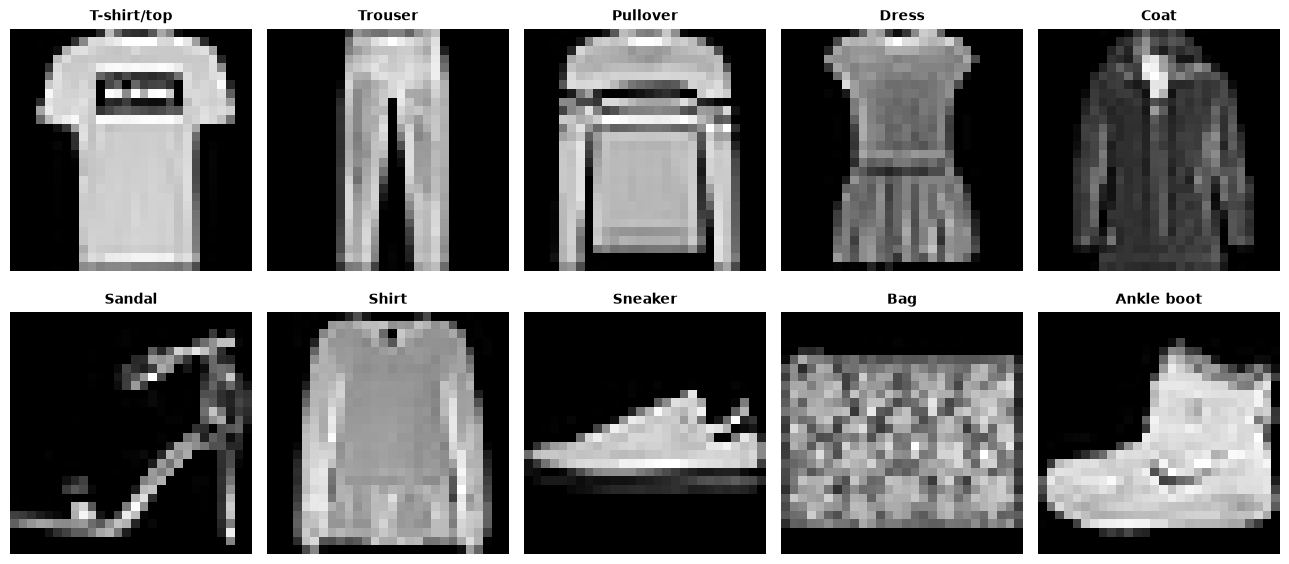

In [3]:
import matplotlib.pyplot as plt

def get_one_per_class(dataset, n_classes=10):
    found = {}
    for img, label in dataset:
        if label not in found:
            found[label] = img
        if len(found) == n_classes:
            break
    return [found[i] for i in range(n_classes)]

samples = get_one_per_class(train_full)

fig1, axes = plt.subplots(2, 5, figsize=(13, 6))

for ax, img, name in zip(axes.flat, samples, CLASS_NAMES):
    # Desnormalizar para mostrar [-1,1] -> [0,1]
    img_np = img.squeeze().numpy()
    img_np = (img_np * 0.5) + 0.5
    ax.imshow(img_np, cmap='gray')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Distribucion de clases

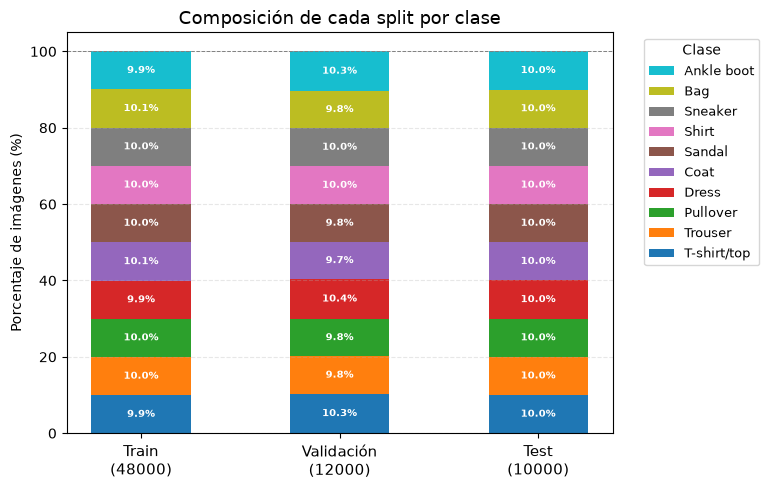

In [4]:
from collections import Counter
import numpy as np

def get_labels(subset):
    if hasattr(subset, 'dataset'):
        return [subset.dataset.targets[i].item() for i in subset.indices]
    else:
        return subset.targets.tolist()

train_labels = get_labels(train_set)
val_labels   = get_labels(val_set)
test_labels  = get_labels(test_set)

def label_counts(labels):
    c = Counter(labels)
    return [c[i] for i in range(10)]

splits = {
    f'Train\n({train_size})': label_counts(train_labels),
    f'Validación\n({val_size})': label_counts(val_labels),
    f'Test\n({len(test_set)})': label_counts(test_labels),
}

splits_pct = {
    name: np.array(counts) / sum(counts) * 100
    for name, counts in splits.items()
}

fig2, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(3)
x = np.arange(3)

for i, class_name in enumerate(CLASS_NAMES):
    values = np.array([splits_pct[split][i] for split in splits_pct])
    bars = ax.bar(x, values, bottom=bottom, label=class_name, width=0.5)

    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 1.5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + val / 2,
                f'{val:.1f}%',
                ha='center', va='center', fontsize=7, color='white', fontweight='bold'
            )
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(list(splits_pct.keys()), fontsize=11)
ax.set_ylabel("Porcentaje de imágenes (%)")
ax.set_title("Composición de cada split por clase", fontsize=13)
ax.set_ylim(0, 105)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.7)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1], labels[::-1],
    loc='upper right', bbox_to_anchor=(1.28, 1), fontsize=9, title="Clase"
)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Rango de valores de los pixeles

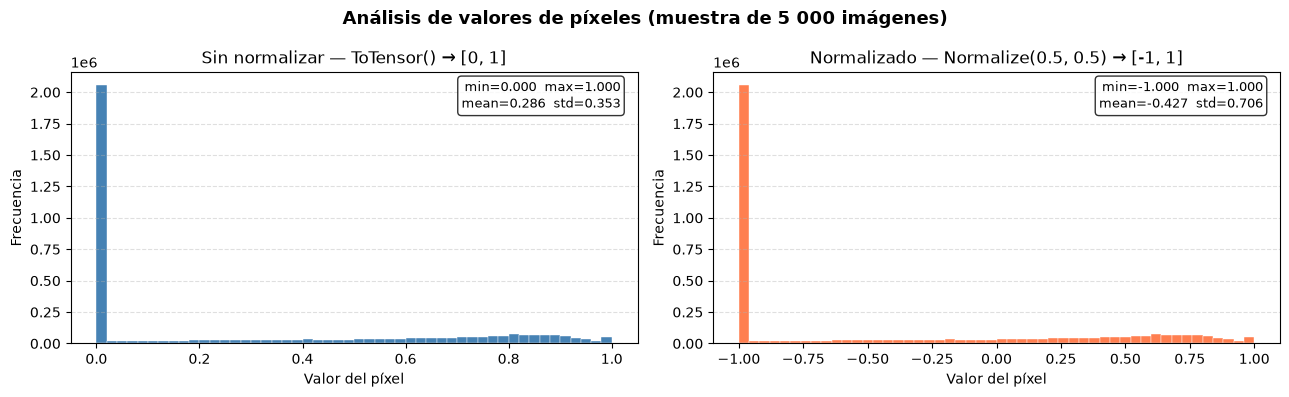

In [5]:
train_counts = label_counts(train_labels)

# calcula stats sobre píxeles RAW (sin normalizar) y normalizados
raw_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=False,
    transform=transforms.ToTensor()
)

# muestra aleatoria de 5000 imagenes
indices = torch.randperm(len(raw_dataset))[:5000]
sample_pixels_raw = torch.stack([raw_dataset[int(i)][0] for i in indices])
sample_pixels_norm = sample_pixels_raw * 2 - 1

fig3, axes3 = plt.subplots(1, 2, figsize=(13, 4))
fig3.suptitle("Análisis de valores de píxeles (muestra de 5 000 imágenes)", fontsize=13, fontweight='bold')

# histograma
ax = axes3[0]
flat_raw = sample_pixels_raw.flatten().numpy()
ax.hist(flat_raw, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title("Sin normalizar — ToTensor() → [0, 1]")
ax.set_xlabel("Valor del píxel")
ax.set_ylabel("Frecuencia")
stats_raw = f"min={flat_raw.min():.3f}  max={flat_raw.max():.3f}\nmean={flat_raw.mean():.3f}  std={flat_raw.std():.3f}"
ax.text(0.97, 0.97, stats_raw, transform=ax.transAxes,
        va='top', ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(axis='y', linestyle='--', alpha=0.4)

# histograma normalizado
ax2 = axes3[1]
flat_norm = sample_pixels_norm.flatten().numpy()
ax2.hist(flat_norm, bins=50, color='coral', edgecolor='white', linewidth=0.3)
ax2.set_title("Normalizado — Normalize(0.5, 0.5) → [-1, 1]")
ax2.set_xlabel("Valor del píxel")
ax2.set_ylabel("Frecuencia")
stats_norm = f"min={flat_norm.min():.3f}  max={flat_norm.max():.3f}\nmean={flat_norm.mean():.3f}  std={flat_norm.std():.3f}"
ax2.text(0.97, 0.97, stats_norm, transform=ax2.transAxes,
         va='top', ha='right', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Forma de las imagenes

In [6]:
shapes = set(raw_dataset[int(i)][0].shape for i in indices)
print(f"Formas únicas en el dataset: {shapes}")

Formas únicas en el dataset: {torch.Size([1, 28, 28])}


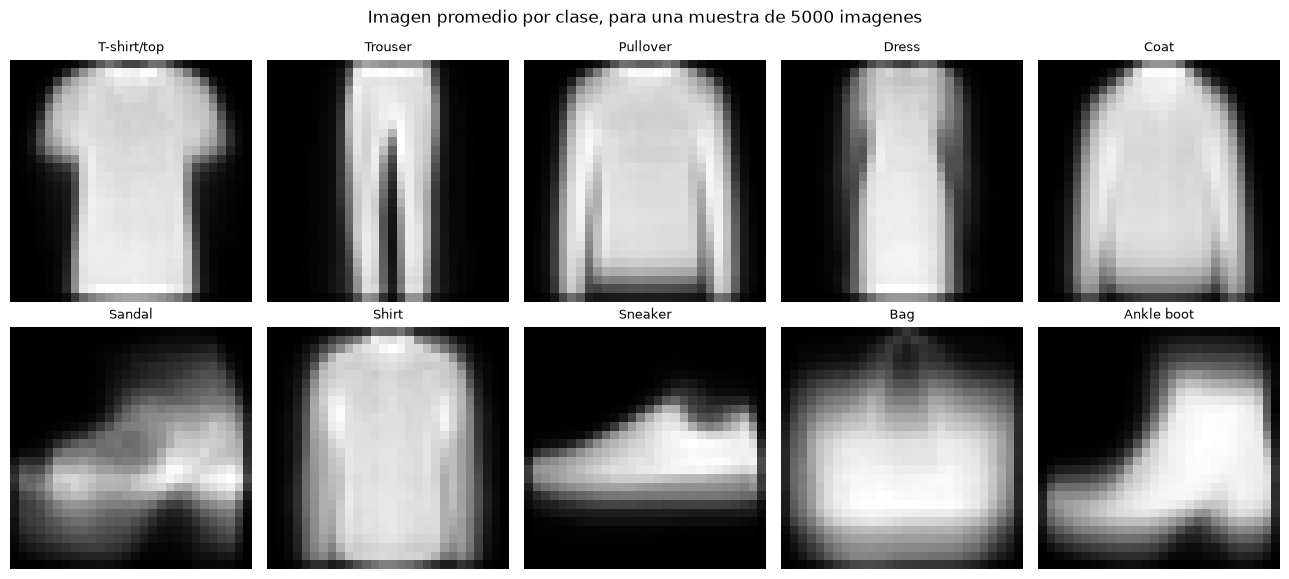

In [7]:
sample_size = min(len(raw_dataset), 5000)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
fig.suptitle(f"Imagen promedio por clase, para una muestra de {sample_size} imagenes")

for class_idx, ax in enumerate(axes.flat):
    imgs = [raw_dataset[int(i)][0] for i in range(sample_size)
            if raw_dataset[int(i)][1] == class_idx]
    mean_img = torch.stack(imgs).mean(dim=0).squeeze()
    ax.imshow(mean_img, cmap='gray')
    ax.set_title(CLASS_NAMES[class_idx], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 3. Preprocesamiento

### Normalizacion de las imagenes
Al inicio de la parte 2, ya se normalizaron las imagenes, para poder hacer correctamente los calculos del analisis, con valores de media y desvio:

In [8]:
print(f"Mean: {mean.item():.4f}") # type: ignore
print(f"Std:  {std.item():.4f}") # type: ignore

Mean: 0.2862
Std:  0.3530


### Aplanado de imagenes

In [9]:
transform_mlp = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(mean.item(),), std=(std.item(),)),  # type: ignore
    transforms.Lambda(lambda x: x.view(-1))
])

# Cargar datasets
train_full_mlp = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=False,
    transform=transform_mlp
)

test_set_mlp = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform_mlp
)

# Split train/validation
val_size_mlp = int(VALIDATION_SPLIT * len(train_full_mlp))
train_size_mlp = len(train_full_mlp) - val_size_mlp

train_set_mlp, val_set_mlp = random_split(
    train_full_mlp,
    [train_size_mlp, val_size_mlp],
    generator=torch.Generator().manual_seed(64)
)

# DataLoaders
train_loader_mlp = DataLoader(train_set_mlp, batch_size=256, shuffle=True)
val_loader_mlp   = DataLoader(val_set_mlp, batch_size=256, shuffle=False)
test_loader_mlp  = DataLoader(test_set_mlp, batch_size=256, shuffle=False)

print("DataLoaders para MLP creados exitosamente.")
images, labels = next(iter(train_loader_mlp))
print(images.shape)

DataLoaders para MLP creados exitosamente.
torch.Size([256, 784])


# 4. Definición de los Modelos

## Modelo 1: MLP (MultiLayer Feedforward)

### Arquitectura MLP Base

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

### Crear modelo, loss y optimizador

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_mlp = FashionMLP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_mlp.parameters(),
    lr=0.001
)

### Función de entrenamiento y evaluación

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

### Entrenamiento del modelo

In [13]:
num_epochs = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model_mlp,
        train_loader_mlp,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model_mlp,
        val_loader_mlp,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/15] Train Loss: 0.6409 | Train Acc: 0.7686 | Val Loss: 0.4202 | Val Acc: 0.8476
Epoch [2/15] Train Loss: 0.4370 | Train Acc: 0.8434 | Val Loss: 0.3656 | Val Acc: 0.8680
Epoch [3/15] Train Loss: 0.3892 | Train Acc: 0.8599 | Val Loss: 0.3406 | Val Acc: 0.8740
Epoch [4/15] Train Loss: 0.3656 | Train Acc: 0.8665 | Val Loss: 0.3270 | Val Acc: 0.8793
Epoch [5/15] Train Loss: 0.3467 | Train Acc: 0.8736 | Val Loss: 0.3329 | Val Acc: 0.8747
Epoch [6/15] Train Loss: 0.3325 | Train Acc: 0.8786 | Val Loss: 0.3093 | Val Acc: 0.8867
Epoch [7/15] Train Loss: 0.3156 | Train Acc: 0.8834 | Val Loss: 0.3092 | Val Acc: 0.8848
Epoch [8/15] Train Loss: 0.3057 | Train Acc: 0.8872 | Val Loss: 0.3067 | Val Acc: 0.8872
Epoch [9/15] Train Loss: 0.2999 | Train Acc: 0.8884 | Val Loss: 0.3006 | Val Acc: 0.8903
Epoch [10/15] Train Loss: 0.2905 | Train Acc: 0.8929 | Val Loss: 0.2946 | Val Acc: 0.8934
Epoch [11/15] Train Loss: 0.2817 | Train Acc: 0.8948 | Val Loss: 0.2994 | Val Acc: 0.8923
Epoch [12/15] Train

### Evaluar en test

              precision    recall  f1-score   support

 T-shirt/top     0.8345    0.8620    0.8480      1000
     Trouser     0.9928    0.9610    0.9766      1000
    Pullover     0.7410    0.8640    0.7978      1000
       Dress     0.8880    0.8800    0.8840      1000
        Coat     0.8136    0.7900    0.8016      1000
      Sandal     0.9822    0.9380    0.9596      1000
       Shirt     0.7427    0.6580    0.6978      1000
     Sneaker     0.9194    0.9700    0.9440      1000
         Bag     0.9856    0.9600    0.9726      1000
  Ankle boot     0.9550    0.9560    0.9555      1000

    accuracy                         0.8839     10000
   macro avg     0.8855    0.8839    0.8838     10000
weighted avg     0.8855    0.8839    0.8838     10000



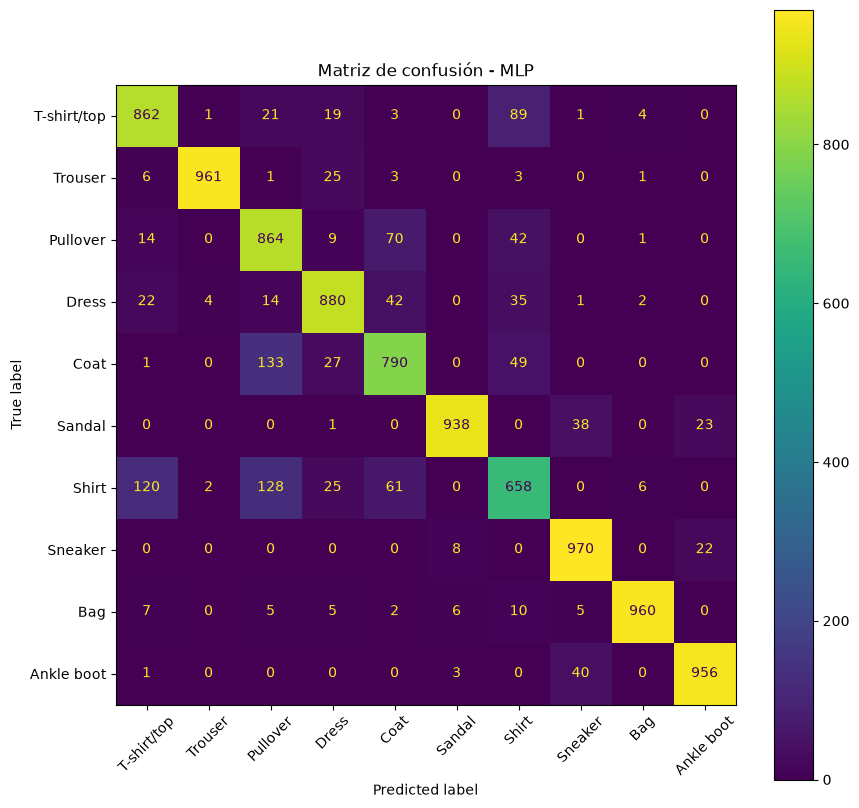

Test Loss: 0.3344
Test Accuracy: 0.8839


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

y_true, y_pred = get_predictions(model_mlp, test_loader_mlp, device)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Matriz de confusión - MLP")
plt.show()

test_loss, test_acc = evaluate(
    model_mlp,
    test_loader_mlp,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

In [15]:
class FlexibleMLP(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size, activation, dropout):
        super().__init__()

        layers = []
        previous_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(previous_size, hidden_size))
            layers.append(activation())
            layers.append(nn.Dropout(dropout))
            previous_size = hidden_size

        layers.append(nn.Linear(previous_size, output_size))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [16]:
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [17]:
def get_optimizer(name, model, lr):
    if name == "Adam":
        return optim.Adam(model.parameters(), lr=lr)

    elif name == "SGD":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    elif name == "RMSprop":
        return optim.RMSprop(model.parameters(), lr=lr)

    else:
        raise ValueError(f"Optimizador no soportado: {name}")

In [18]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        avg_train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        avg_val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

    return history

In [19]:
experiments = [
    {
        "name": "MLP_256_128_ReLU_Adam",
        "hidden_layers": [256, 128],
        "activation": nn.ReLU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_512_256_128_ReLU_Adam",
        "hidden_layers": [512, 256, 128],
        "activation": nn.ReLU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_256_128_LeakyReLU_Adam",
        "hidden_layers": [256, 128],
        "activation": nn.LeakyReLU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_256_128_GELU_Adam",
        "hidden_layers": [256, 128],
        "activation": nn.GELU,
        "dropout": 0.3,
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs": 15
    },
    {
        "name": "MLP_512_256_ReLU_RMSprop",
        "hidden_layers": [512, 256],
        "activation": nn.ReLU,
        "dropout": 0.2,
        "optimizer": "RMSprop",
        "lr": 0.0005,
        "epochs": 15
    }
]

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results = []

criterion = nn.CrossEntropyLoss()

for exp in experiments:
    print(f"Entrenando experimento: {exp['name']}")

    model = FlexibleMLP(
        input_size=784,
        hidden_layers=exp["hidden_layers"],
        output_size=10,
        activation=exp["activation"],
        dropout=exp["dropout"]
    ).to(device)

    optimizer = get_optimizer(
        name=exp["optimizer"],
        model=model,
        lr=exp["lr"]
    )

    history = train_model(
        model=model,
        train_loader=train_loader_mlp,
        val_loader=val_loader_mlp,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=exp["epochs"]
    )

    y_true, y_pred = get_predictions(
        model,
        test_loader_mlp,
        device
    )

    test_acc = accuracy_score(y_true, y_pred)
    test_precision = precision_score(y_true, y_pred, average="macro")
    test_recall = recall_score(y_true, y_pred, average="macro")
    test_f1 = f1_score(y_true, y_pred, average="macro")

    results.append({
        "model": exp["name"],
        "hidden_layers": exp["hidden_layers"],
        "activation": exp["activation"].__name__,
        "dropout": exp["dropout"],
        "optimizer": exp["optimizer"],
        "lr": exp["lr"],
        "epochs": exp["epochs"],
        "final_train_loss": history["train_loss"][-1],
        "final_train_acc": history["train_acc"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_acc": history["val_acc"][-1],
        "test_acc": test_acc,
        "test_precision_macro": test_precision,
        "test_recall_macro": test_recall,
        "test_f1_macro": test_f1
    })

    print(f"Finalizado: {exp['name']}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test F1 Macro: {test_f1:.4f}")
    print("-" * 50)

Entrenando experimento: MLP_256_128_ReLU_Adam
Finalizado: MLP_256_128_ReLU_Adam
Test Accuracy: 0.8877
Test F1 Macro: 0.8869
--------------------------------------------------
Entrenando experimento: MLP_512_256_128_ReLU_Adam


KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["test_acc", "test_f1_macro"],
    ascending=False
)

results_df

## Modelo 2: CNN (Convolucional)

### Arquitectura CNN Base

In [21]:
import torch
from torch import optim
from torch import nn
from tqdm import tqdm
from dataclasses import dataclass, field
from typing import Literal

# import torchvision

import torch.nn.functional as F
# import torchvision.datasets as datasets
# import torchvision.transforms as transforms

############################
# configuracion de la cnn
############################
@dataclass
class ConvLayerConfig:
    out_channels: int
    kernel_size: int = 3
    padding: int = 1
    activation: Literal["relu", "tanh", "leaky_relu", "elu", "none"] = "relu"
    pooling: Literal["max", "avg", "none"] = "max"
    use_batchnorm: bool = False
    dropout_p: float = 0.0

@dataclass
class LinearLayerConfig:
    out_features: int
    activation: Literal["relu", "tanh", "leaky_relu", "elu", "none"] = "relu"
    dropout_p: float = 0.0

@dataclass
class TrainConfig:
    num_epochs:   int   = 10
    lr:           float = 0.001
    weight_decay: float = 0.0   # L2 — 0.0 = desactivado
    l1_lambda:    float = 0.0   # L1 — 0.0 = desactivado
    patience:     int   = 0     # early stopping — 0 = desactivado


##################
# helpers
##################
ACTIVATIONS = {
    "relu":       nn.ReLU(),
    "tanh":       nn.Tanh(),
    "leaky_relu": nn.LeakyReLU(),
    "elu":        nn.ELU(),
    "none":       nn.Identity(),
}

POOLING = {
    "max": nn.MaxPool2d(kernel_size=2, stride=2),
    "avg": nn.AvgPool2d(kernel_size=2, stride=2),
    "none": nn.Identity(),
}


######################
# modelo
######################
class CNN(nn.Module):
    def __init__(
        self, 
        in_channels: int, 
        input_size: int, # ancho, alto de la img
        num_classes: int,
        conv_layers: list[ConvLayerConfig],
        linear_layers: list[LinearLayerConfig],
        ):
       
        super().__init__()

        conv_blocks = []
        current_channels = in_channels

        for cfg in conv_layers:
            conv_blocks += [
                nn.Conv2d(current_channels, cfg.out_channels,
                          kernel_size=cfg.kernel_size, padding=cfg.padding),
                nn.BatchNorm2d(cfg.out_channels) if cfg.use_batchnorm else nn.Identity(),
                ACTIVATIONS[cfg.activation],
                POOLING[cfg.pooling],
                nn.Dropout2d(cfg.dropout_p) if cfg.dropout_p > 0 else nn.Identity(),
            ]
            current_channels = cfg.out_channels
            if cfg.pooling != "none":
                input_size //= 2

        self.conv_net = nn.Sequential(*conv_blocks)

        flatten_size = current_channels * input_size * input_size
        linear_blocks = []
        current_features = flatten_size

        for cfg in linear_layers:
            linear_blocks += [
                nn.Linear(current_features, cfg.out_features),
                ACTIVATIONS[cfg.activation],
                nn.Dropout(cfg.dropout_p) if cfg.dropout_p > 0 else nn.Identity(),
            ]
            current_features = cfg.out_features

        linear_blocks.append(nn.Linear(current_features, num_classes))
        self.linear_net = nn.Sequential(*linear_blocks)


    def forward(self, x):
        x = self.conv_net(x)
        x = x.reshape(x.shape[0], -1)
        x = self.linear_net(x)
        return x


### Función de entrenamiento y evaluación

In [22]:
def train(
    model: CNN,
    train_loader,
    cfg: TrainConfig,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    history = {"train_loss": []}

    for epoch in range(cfg.num_epochs):
        model.train()
        train_loss = 0.0

        for data, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.num_epochs}"):
            data, targets = data.to(device), targets.to(device)

            optimizer.zero_grad()
            scores = model(data)
            loss   = criterion(scores, targets)

            if cfg.l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss    = loss + cfg.l1_lambda * l1_norm

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        history["train_loss"].append(train_loss)
        print(f"  train_loss: {train_loss:.4f}")

    return model, history

### Test

In [23]:
import os


FORCE_RETRAIN = False


experiments = [
    {
        "name": "baseline",
        "conv_layers": [
            ConvLayerConfig(out_channels=8),
            ConvLayerConfig(out_channels=16),
        ],
        "linear_layers": [
            LinearLayerConfig(out_features=128),
        ],
        "train_cfg": TrainConfig(),
    },
    {
        "name": "l2 + dropout",
        "conv_layers": [
            ConvLayerConfig(out_channels=32, use_batchnorm=True),
            ConvLayerConfig(out_channels=64, use_batchnorm=True, dropout_p=0.25),
        ],
        "linear_layers": [
            LinearLayerConfig(out_features=256, dropout_p=0.5),
            LinearLayerConfig(out_features=128, dropout_p=0.25),
        ],
        "train_cfg": TrainConfig(weight_decay=1e-4, patience=3),
    },
    {
        "name": "l1 + early stopping",
        "conv_layers": [
            ConvLayerConfig(out_channels=32, use_batchnorm=True),
            ConvLayerConfig(out_channels=64, use_batchnorm=True),
        ],
        "linear_layers": [
            LinearLayerConfig(out_features=128),
        ],
        "train_cfg": TrainConfig(l1_lambda=1e-5, patience=3),
    },
    {
        "name": "todo",
        "conv_layers": [
            ConvLayerConfig(out_channels=32, use_batchnorm=True, activation="leaky_relu"),
            ConvLayerConfig(out_channels=64, use_batchnorm=True, dropout_p=0.25),
        ],
        "linear_layers": [
            LinearLayerConfig(out_features=256, dropout_p=0.5),
            LinearLayerConfig(out_features=128, dropout_p=0.25),
        ],
        "train_cfg": TrainConfig(l1_lambda=1e-5, weight_decay=1e-4, patience=3),
    },
]

trained_models = {}
results = {}
save_path = "models"
os.makedirs(save_path, exist_ok=True)

for exp in experiments:
    print(f"\n{'='*40}\nExperimento: {exp['name']}\n{'='*40}")

    model = CNN(
        in_channels=1,
        input_size=28,
        num_classes=10,
        conv_layers=exp["conv_layers"],
        linear_layers=exp["linear_layers"],
    )

    model_path = os.path.join(save_path, f"{exp['name']}_final.pth")

    if not FORCE_RETRAIN and os.path.exists(model_path):
        print(f"  Cargando modelo existente desde {model_path}")
        model.load_state_dict(torch.load(model_path))
        results[exp["name"]] = None  # no hay history si no se entreno
    else:
        model, history = train(model, train_loader, cfg=exp["train_cfg"])
        torch.save(model.state_dict(), model_path)
        results[exp["name"]] = history

    model.eval()
    trained_models[exp["name"]] = model


Experimento: baseline


Epoch 1/10: 100%|██████████| 188/188 [00:08<00:00, 22.74it/s]


  train_loss: 0.7055


Epoch 2/10: 100%|██████████| 188/188 [00:07<00:00, 25.80it/s]


  train_loss: 0.4201


...

  train_loss: 0.3694


Epoch 9/10: 100%|██████████| 188/188 [00:08<00:00, 23.26it/s]


  train_loss: 0.3575


Epoch 10/10: 100%|██████████| 188/188 [00:07<00:00, 24.22it/s]

  train_loss: 0.3485


### Evaluacion


Evaluación: baseline
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1238
           1       0.99      0.98      0.98      1177
           2       0.81      0.88      0.84      1180
           3       0.87      0.95      0.91      1247
           4       0.90      0.74      0.81      1169
           5       0.98      0.97      0.97      1182
           6       0.77      0.69      0.73      1199
           7       0.95      0.97      0.96      1194
           8       0.98      0.97      0.98      1174
           9       0.97      0.96      0.97      1240

    accuracy                           0.90     12000
   macro avg       0.90      0.90      0.90     12000
weighted avg       0.90      0.90      0.90     12000



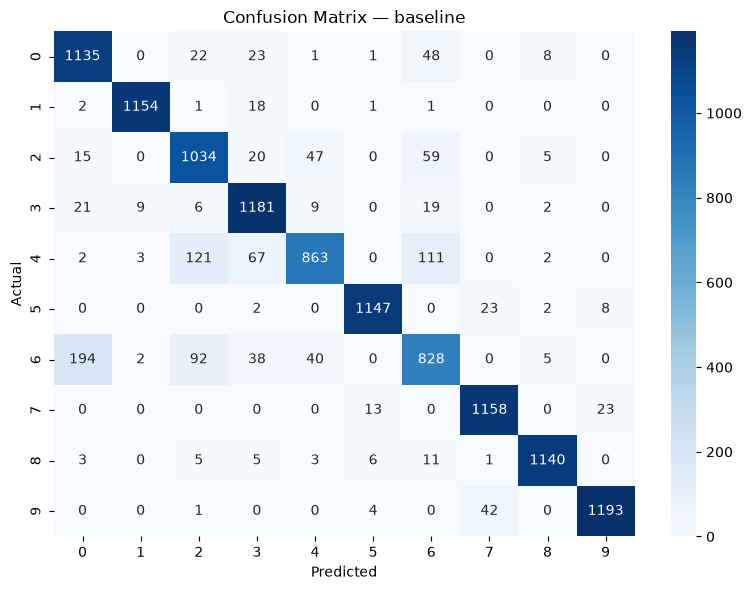


Evaluación: l2 + dropout
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      1238
           1       0.98      0.99      0.99      1177
           2       0.86      0.89      0.87      1180
           3       0.92      0.94      0.93      1247
           4       0.85      0.89      0.87      1169
           5       0.99      0.98      0.98      1182
           6       0.84      0.72      0.77      1199
           7       0.95      0.98      0.97      1194
           8       0.99      0.98      0.99      1174
           9       0.98      0.96      0.97      1240

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



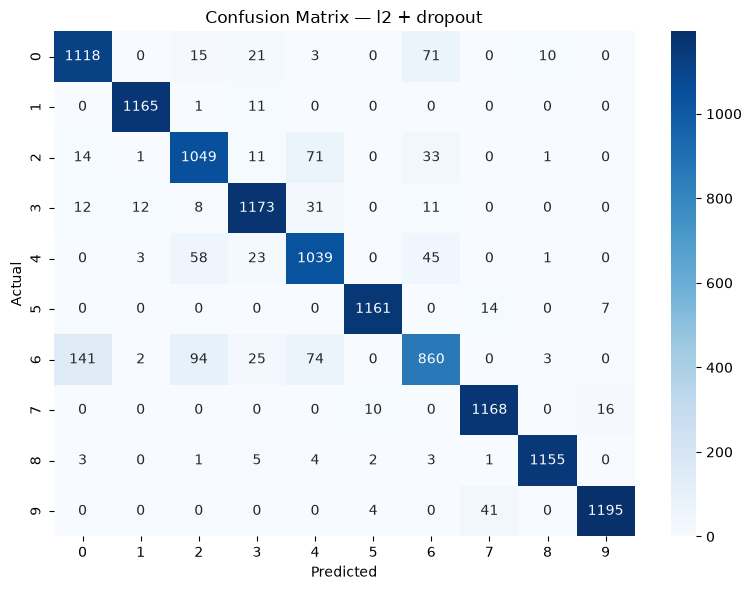


Evaluación: l1 + early stopping
              precision    recall  f1-score   support

           0       0.94      0.80      0.86      1238
           1       1.00      0.98      0.99      1177
           2       0.90      0.81      0.86      1180
           3       0.91      0.96      0.93      1247
           4       0.89      0.85      0.87      1169
           5       0.95      0.99      0.97      1182
           6       0.70      0.89      0.78      1199
           7       0.97      0.94      0.96      1194
           8       0.99      0.98      0.98      1174
           9       0.97      0.96      0.97      1240

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



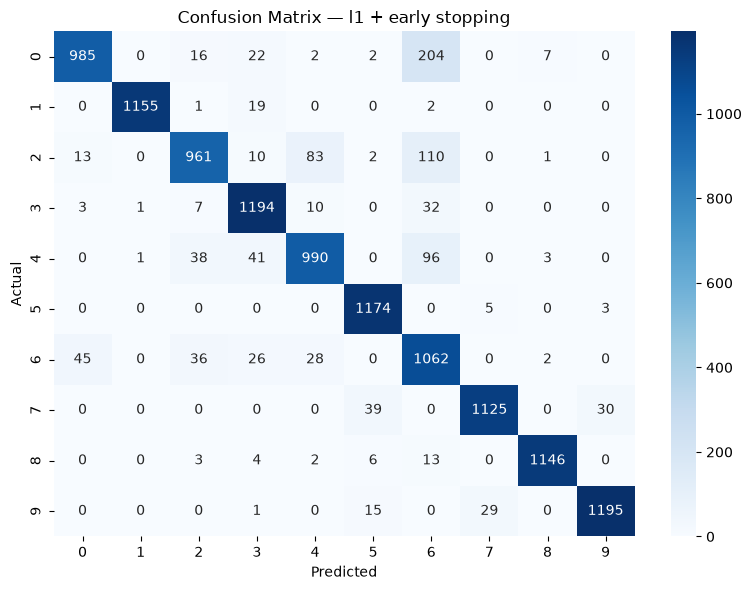


Evaluación: todo
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1238
           1       0.99      0.99      0.99      1177
           2       0.86      0.88      0.87      1180
           3       0.95      0.91      0.93      1247
           4       0.85      0.87      0.86      1169
           5       0.97      0.99      0.98      1182
           6       0.80      0.75      0.77      1199
           7       0.96      0.95      0.96      1194
           8       0.98      0.98      0.98      1174
           9       0.98      0.96      0.97      1240

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000



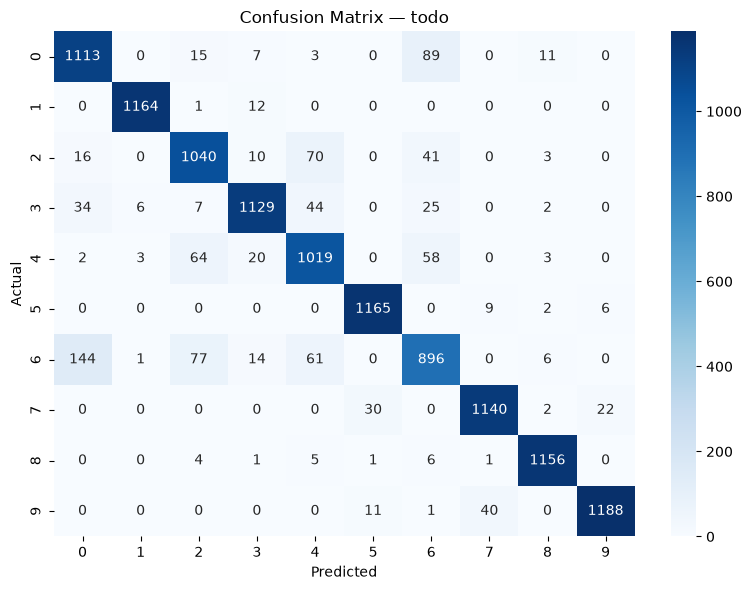

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

for name, model in trained_models.items():
    print(f"\n{'='*40}\nEvaluación: {name}\n{'='*40}")

    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for data, targets in val_loader:
            data = data.to(device)
            preds = model(data).argmax(dim=1).cpu()
            all_preds.extend(preds.tolist())
            all_targets.extend(targets.tolist())

    # Métricas
    print(classification_report(all_targets, all_preds))

    # Matriz de confusión
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

### Load and save models

# 5. Experimentación

# 6. Discusión

# 7. Conclusiones y Trabajo Futuro